## Упражнение

- Загрузите и нанесите на график исторические цены закрытия Tesla (``TSLA``) и Equinor (``EQNR``) за годы ``2019-12-31``- ``2022-12-31``.
- Для каждого временного ряда:
    - Проверьте, выглядит ли временной ряд стационарным.
    - Вычислите коэффициент Херста для обоих временных рядов.
    - В какие акции вы хотели бы инвестировать? Обоснуйте свой ответ на основе тестов и значения $H$.
    - Смоделируйте цены акций с помощью GBM.

- Какая симуляция кажется более надежной? Для Tesla или Equinor?
- Чтобы обосновать свой ответ:
1. вычислите симуляцию не менее 100 раз.
2. Вычислите MSE между истинными ценами акций и смоделированными.
3. Сравните ожидаемое значение MAPE для двух акций.

**Упрежнение:**

In [9]:
# Загрузка данных

import yfinance as yf

def get_data(tickerSymbol, start, end):

    # Get data on the ticker
    tickerData = yf.Ticker(tickerSymbol)

    # Get the historical prices for this ticker
    tickerDf = tickerData.history(start=start, end=end)

    return tickerDf

data_tsla = get_data('TSLA', start='2019-12-31', end='2022-12-31')
data_eqnr = get_data('EQNR', start='2019-12-31', end='2022-12-31')

In [27]:
test_tsla = get_data('TSLA', start='2022-12-31', end='2023-12-31')
test_eqnr = get_data('EQNR', start='2022-12-31', end='2023-12-31')

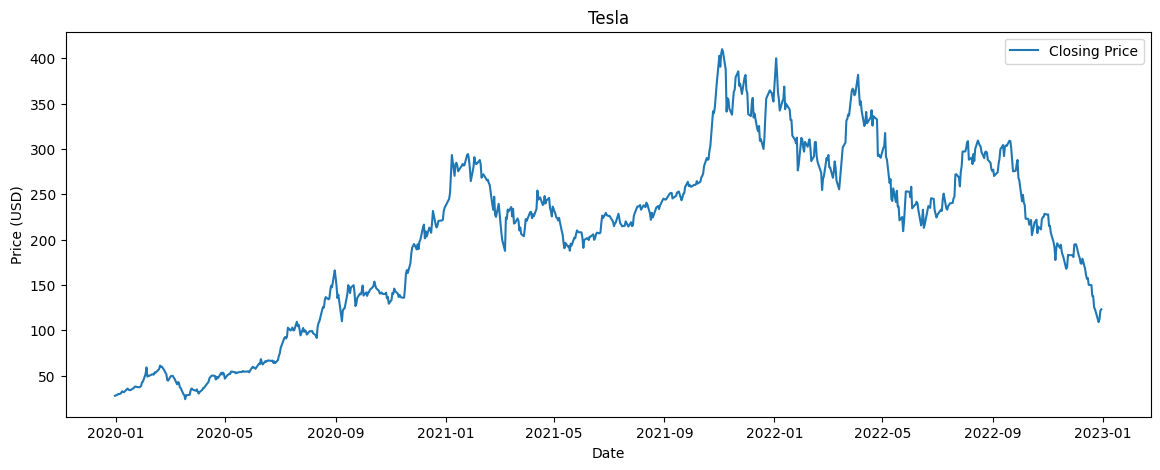

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(data_tsla['Close'], label='Closing Price')
plt.title('Tesla')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()

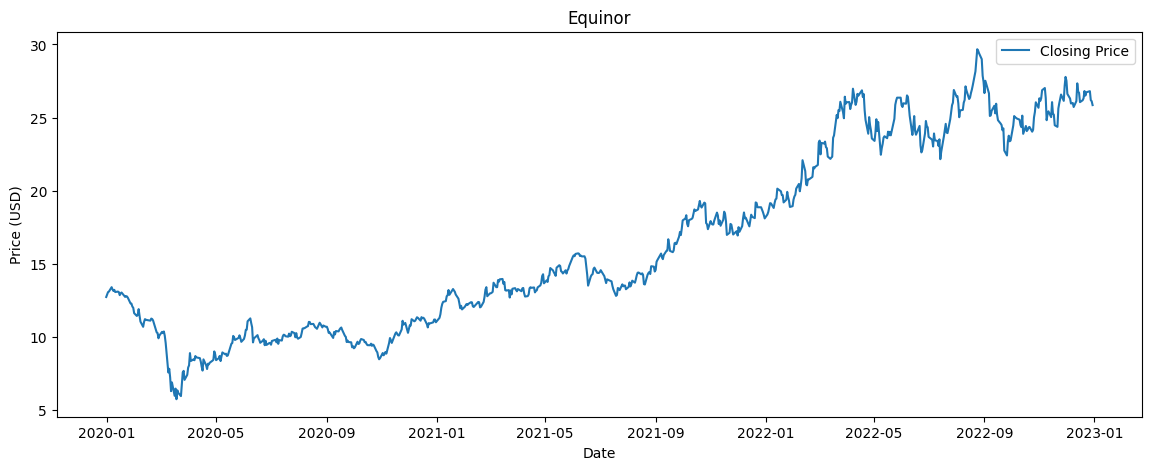

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(data_eqnr['Close'], label='Closing Price')
plt.title('Equinor')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()

In [19]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF test
def perform_adf_test(series, title, regression_type):
    out = adfuller(series, regression=regression_type, result_object=False)
    print(f"Results for {title}:")
    print(f'ADF Statistic: {out[0]:.2f}')
    print(f'p-value: {out[1]:.3f}')
    print(f"Critical Values: {[f'{k}: {r:.2f}' for r,k in zip(out[4].values(), out[4].keys())]}\n")

perform_adf_test(data_tsla['Close'],"Tesla Stock Closing Prices", 'ct')

Results for Tesla Stock Closing Prices:
ADF Statistic: -0.93
p-value: 0.953
Critical Values: ['1%: -3.97', '5%: -3.42', '10%: -3.13']



In [20]:
perform_adf_test(data_eqnr['Close'],"Equinor Stock Closing Prices", 'ct')

Results for Equinor Stock Closing Prices:
ADF Statistic: -3.60
p-value: 0.030
Critical Values: ['1%: -3.97', '5%: -3.42', '10%: -3.13']



**Временные ряды не стационарны**

In [23]:
import numpy as np

def hurst(ts):

    # Create the range of lag values
    lags = range(2, 100)

    # Calculate the array of the variances of the lagged differences
    tau = [np.var(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]

    # Use a linear fit to estimate the Hurst Exponent
    poly = np.polyfit(np.log(lags), np.log(tau), 1)

    # Return the Hurst exponent from the polyfit output
    return poly[0]/2.0

H_tsla = hurst(data_tsla['Close'].values)
print(f"Оценка показателя Хёрста(Tesla): H ≈ {H_tsla:.2f}")

Оценка показателя Хёрста(Tesla): H ≈ 0.46


In [24]:
H_eqnr = hurst(data_eqnr['Close'].values)
print(f"Оценка показателя Хёрста(Equinor): H ≈ {H_eqnr:.2f}")

Оценка показателя Хёрста(Equinor): H ≈ 0.33


Выгоднее будет купить акции Equinor, так у них более вероятно, что акции вернутся к среднему значению, они более предсказуемые.<br>А у Tesla показатель Хёрста близкий к 0.5, что говорит, что цены следуют случайному блужданию.

In [40]:
def calculate_gbm_parameters(prices, n_days):
    mu = prices.pct_change().mean() * 252
    sigma = prices.pct_change().std() * np.sqrt(252)

    T = 1
    dt = 1 / n_days
    N = int(T / dt)
    time_step = np.linspace(0, T, N)
    S0 = prices.iloc[-1]

    return mu, sigma, S0, time_step, N, dt

In [42]:
mu_tsla, sigma_tsla, S0_tsla, time_step_tsla, N_tsla, dt_tsla = calculate_gbm_parameters(
    data_tsla['Close'], len(test_tsla))
mu_eqnr, sigma_eqnr, S0_eqnr, time_step_eqnr, N_eqnr, dt_eqnr = calculate_gbm_parameters(
    data_eqnr['Close'], len(test_eqnr))

print(f"\nПараметры GBM:")
print(f"Tesla: S0 = {S0_tsla:.2f}, μ = {mu_tsla:.4f}, σ = {sigma_tsla:.4f}")
print(f"Equinor: S0 = {S0_eqnr:.2f}, μ = {mu_eqnr:.4f}, σ = {sigma_eqnr:.4f}")


Параметры GBM:
Tesla: S0 = 123.18, μ = 0.7556, σ = 0.7216
Equinor: S0 = 25.85, μ = 0.3374, σ = 0.4472


In [43]:
def simulate_gbm(S0, mu, sigma, n_days, n_simulations=100, time_step=1):

    paths = np.empty((n_simulations, n_days))
    dt = 1 / n_days

    for i in range(n_simulations):
        W = np.cumsum(np.random.standard_normal(size=n_days)) * np.sqrt(dt)
        X = (mu - 0.5 * sigma**2) * time_step[:n_days] + sigma * W
        paths[i] = S0 * np.exp(X)

    return paths

In [44]:
n_simulations = 1000


sim_tsla = simulate_gbm(S0_tsla, mu_tsla, sigma_tsla, len(test_tsla), n_simulations, time_step_tsla)
sim_eqnr = simulate_gbm(S0_eqnr, mu_eqnr, sigma_eqnr, len(test_eqnr), n_simulations, time_step_eqnr)

In [45]:
def calculate_metrics(real_prices, simulations):
    mse_values = mean_squared_error(real_prices, simulations)
    mape = mean_absolute_percentage_error(real_prices, simulations)

    return mse_values, mape

In [49]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

mse_tsla, mape_tsla = calculate_metrics(test_tsla['Close'], sim_tsla[n_simulations-1])
mse_eqnr, mape_eqnr = calculate_metrics(test_eqnr['Close'], sim_eqnr[n_simulations-1])


print(f"MSE Tesla:    {np.mean(mse_tsla):.2f}")
print(f"MSE Equinor:  {np.mean(mse_eqnr):.2f}")
print(f"MAPE Tesla:   {np.mean(mape_tsla):.2f}")
print(f"MAPE Equinor: {np.mean(mape_eqnr):.2f}")

MSE Tesla:    10626.34
MSE Equinor:  63.82
MAPE Tesla:   0.44
MAPE Equinor: 0.27


In [50]:
path_mean_tsla = np.array(sim_tsla).mean(axis=0)
path_std_tsla = np.array(sim_tsla).std(axis=0)

path_mean_eqnr = np.array(sim_eqnr).mean(axis=0)
path_std_eqnr = np.array(sim_eqnr).std(axis=0)

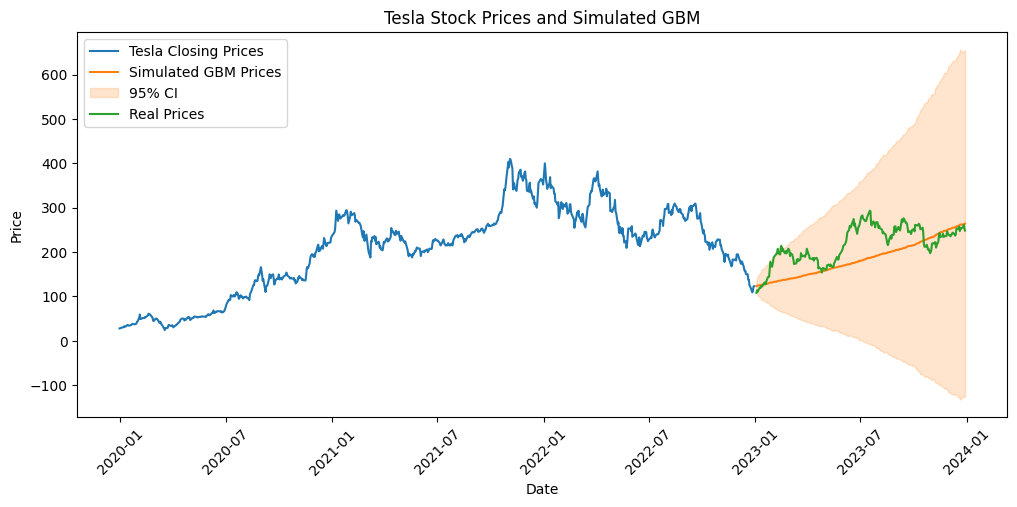

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(data_tsla['Close'], label='Tesla Closing Prices')
plt.plot(test_tsla.index, path_mean_tsla, label='Simulated GBM Prices')
plt.fill_between(test_tsla.index, path_mean_tsla-1.96*path_std_tsla, path_mean_tsla+1.96*path_std_tsla, color='tab:orange', alpha=0.2, label='95% CI')
plt.plot(test_tsla['Close'], label='Real Prices')
plt.legend(loc='upper left')
plt.title('Tesla Stock Prices and Simulated GBM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45);

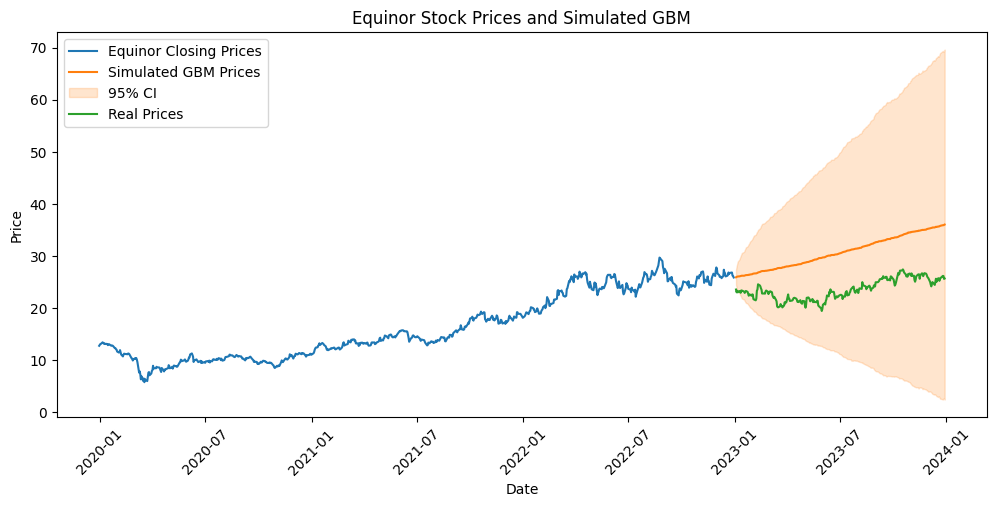

In [52]:
plt.figure(figsize=(12, 5))
plt.plot(data_eqnr['Close'], label='Equinor Closing Prices')
plt.plot(test_eqnr.index, path_mean_eqnr, label='Simulated GBM Prices')
plt.fill_between(test_eqnr.index, path_mean_eqnr-1.96*path_std_eqnr, path_mean_eqnr+1.96*path_std_eqnr, color='tab:orange', alpha=0.2, label='95% CI')
plt.plot(test_eqnr['Close'], label='Real Prices')
plt.legend(loc='upper left')
plt.title('Equinor Stock Prices and Simulated GBM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45);

Симуляция Equinor кажется более надёжной, так как график более линейный и имеет меньшею MSE